## `bias_photometric`
---------------------

This notebook is used for the appendix plot to deal with the bias correction on the photometric sample with tomographic bins $\Delta z=0.1$.
Credit to the original idea of this notebook is attributed to William d'Assises Doumerg; the notebook has been adapted to use the distributions used in this analysis.

In [7]:
import pyccl as ccl
import matplotlib.pyplot as plt
import numpy as np

from scipy import interpolate
from scipy.stats import norm
from pathlib import Path

import src.analysis.plots as plots
import src.statistics.inference as inference
import src.statistics.corrfiles as cf
import src.statistics.cosmotools as ct

PAPER_FIGURES_ROOT = Path(
    "/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/paper/figures/"
)
pm = plots.PlotManager(root=PAPER_FIGURES_ROOT, overwrite=True)

# 0- $\omega_{dm}$ Correlation

$\xi_{dm}(\theta,z)=\frac{H_0}{c}\frac{1}{\chi^2(z)}\sum_\ell \frac{2\ell+1}{4\pi} P_{\delta}(k=\frac{l+1/2}{\chi(z)},z) \mathcal{P}_{l}(\cos \theta)$

Then:
$\omega_{dm}(z)=\int d\theta W(\theta) \xi_{dm}(\theta,z)$. 

We procceed as follow:
- we generate the list $\{\ell\}$
-  we compute the associated angular power spectrum $P(k(l),z)$
- we use the correlation.correlation module to evaluate $\sum_{\ell}...$ given our power spectrum model
- we integrate it for our min-max projected scales (converted to angle) to have $\omega_{dm}$


### We use the $r_p$ scale convention

In [57]:
ROOT = Path("/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/statistics/")
stem = "outputs/calibration"
version = "vF"
path_dictionary = {
    "dr1": {
        "HSC": ROOT / stem / f"autos_HSC",
        "DESI_NGC": ROOT / stem / "dr1" / f"autos_NGC",
        "DESI_SGC": ROOT / stem / "dr1" / f"autos_SGC",
        "DESIxHSC": ROOT / stem / "dr1" / f"cross",
    },
    "dr2": {
        "HSC": ROOT / stem / f"autos_HSC",
        "DESI_NGC": ROOT / stem / "dr2" / f"autos_NGC",
        "DESI_SGC": ROOT / stem / "dr2" / f"autos_SGC",
        "DESIxHSC": ROOT / stem / "dr2" / f"cross",
    },
}
assert all([pv.exists() for p in path_dictionary.values() for pv in p.values()])

# scale cut used in Mpc/h (fiducial)
scale_cut = [0.3, 3]
correction_file_reader = cf.CorrFileReader(path_dictionary["dr2"]["HSC"])
# scales in Mpc/h for wdm calculation
rp_wdm = np.linspace(scale_cut[0], scale_cut[1], 100)

## load nz from photo-z bias splines
data_galbias = np.load(
    ROOT
    / f"results/photoz_bias_splines_{scale_cut[0]}_{scale_cut[1]}_{version}/tomo_photoz.npz"
)
correction_file_reader = cf.CorrFileReader(path_dictionary["dr2"]["HSC"])
bins_z_photo = inference._get_fine_redshift_bins(
    fr=correction_file_reader, tracer="HSC"
)
vals_z_photo = (bins_z_photo[:-1] + bins_z_photo[1:]) / 2
nz_bins = []
zlim = 1.6  # truncate useful bins to 1.6
vals_z_photo = vals_z_photo[vals_z_photo < zlim]

zv = np.linspace(0.005, 2.1, 500)
for i in range(len(vals_z_photo)):
    redshifts = data_galbias[f"{i+1}/redshifts"]
    nz_med = data_galbias[f"{i+1}/nz_median"]
    normal = np.trapezoid(nz_med, x=redshifts)

    nz_med_interp = np.interp(zv, redshifts, nz_med / normal, left=0, right=0)
    # for good measure, re normalize again
    nz_bins.append(nz_med_interp / np.trapezoid(nz_med_interp, x=zv))

In [58]:
z_support = np.linspace(0.005, 3.2, 151)
w_dm_values = [ct.w_dm(rp_vals=rp_wdm, z=z, integrate=True) for z in z_support]
wm = interpolate.interp1d(x=z_support, y=w_dm_values)
wm_v = wm(zv)

## 1) Introduce n(z) and bias
----------------------------


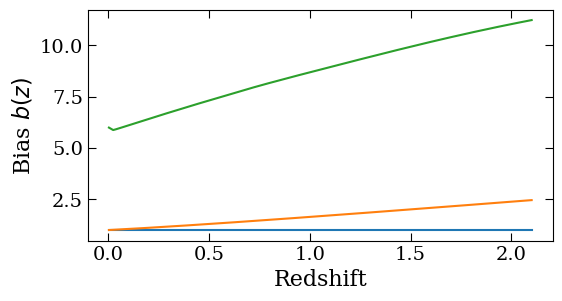

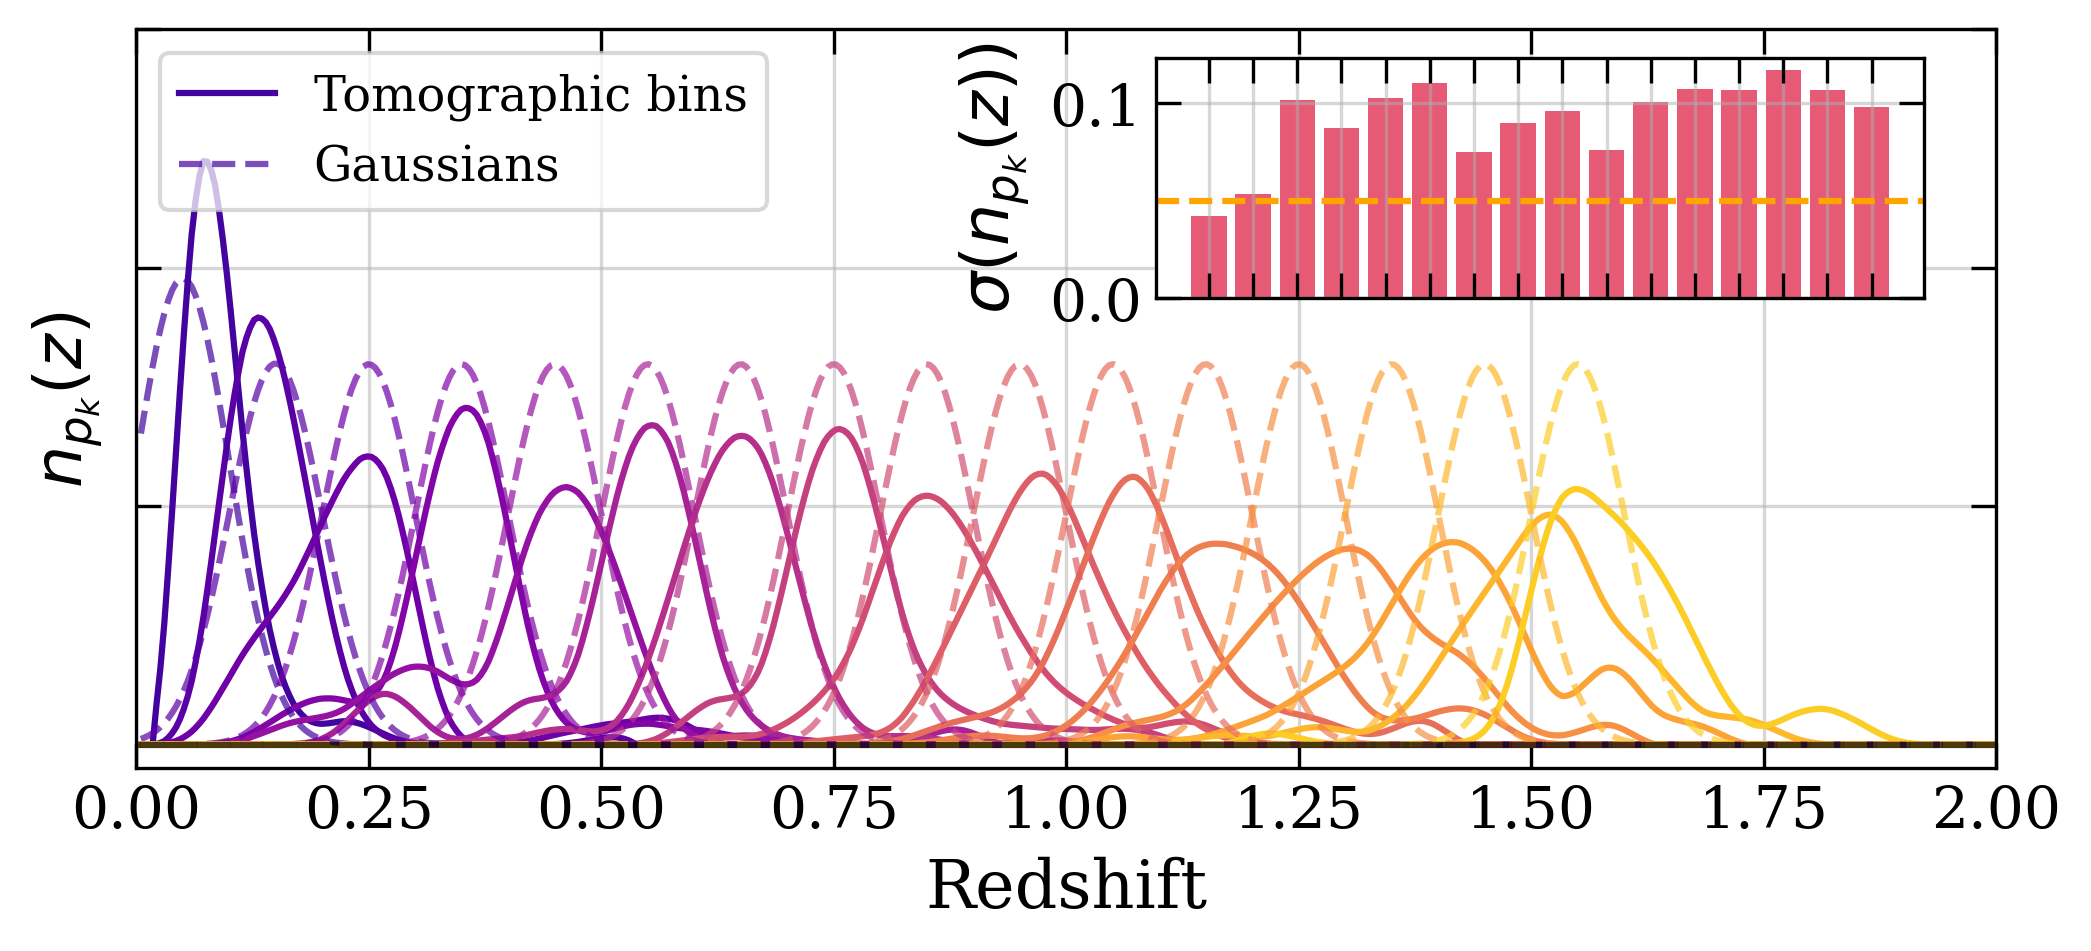

In [59]:
# we use a 1/D(z) bias model computed with ccl.
cmap = plt.get_cmap("plasma")
bias_models = {
    "No": lambda z: np.ones_like(z),
    "Passive": lambda z: 1
    / ccl.background.growth_factor(cosmo=ct.COSMO_ccl, a=1 / (1 + z)),
    #'Strong' : lambda z: 1 + z**2,
    "Strong": lambda z: 1 / np.sqrt(wm(z)),
}
gaussian_scale = 0.05
nz_models = {
    "Tomographic bins": nz_bins,
    "Gaussians": [
        norm.pdf(zv, loc=vals_z_photo[i], scale=gaussian_scale)
        for i in range(len(vals_z_photo))
    ],
    #    'Top-hat' : [
    #        np.where(
    #            (zv >= vals_z_photo[i] - 0.05) & (zv < vals_z_photo[i] + 0.05),
    #            1.0,
    #            0.0
    #        ) for i in range(len(vals_z_photo))
    #    ]
}
# norm to integrate to 1
for name, nzs in nz_models.items():
    for i in range(len(nzs)):
        nzs[i] = nzs[i] / np.trapezoid(nzs[i], zv)

plt.figure(dpi=100, figsize=(6, 3))
plt.grid()
for name, bias in bias_models.items():
    plt.plot(zv, bias(zv), label=name + " evolution")
plt.ylabel(r"Bias $b(z)$")
plt.xlabel(r"Redshift")

with pm.make_plot(
    name="photoz_bias_models", figsize=(8, 3.2), tight_layout=False, show=True
) as (fig, ax1):
    ax1.grid()
    for name, nzs in nz_models.items():
        for i in range(len(nzs)):
            if name != "Top-hat":
                ax1.plot(
                    zv,
                    nzs[i],
                    label=name if i == 0 else "",
                    alpha=(
                        1
                        if name == "Tomographic bins"
                        else (0.4 if name == "Top-hat" else 0.7)
                    ),
                    linestyle=(
                        "--"
                        if name == "Gaussians"
                        else (":" if name == "Top-hat" else "-")
                    ),
                    color=cmap((i + 2) / (len(nzs) + 3)),
                )
    ax1.set_ylabel(r"$n_{p_k}(z)$")
    ax1.set_xlabel(r"Redshift")
    ax1.grid()
    ax1.set_xlim(0.0, 2.0)
    ax1.set_ylim(-0.5, 15)
    ax1.set_yticklabels([])
    ax2 = plt.axes([0.55, 0.6, 0.32, 0.25])
    means = [np.trapezoid(zv * nz, zv) for nz in nz_bins]
    s1 = [
        np.sqrt(np.trapezoid((zv - m) ** 2 * nz, zv)) for m, nz in zip(means, nz_bins)
    ]
    ax2.bar(range(len(s1)), s1, color="crimson", alpha=0.7)
    ax2.axhline(gaussian_scale, color="orange", linestyle="--", alpha=1, linewidth=1.5)
    ax2.set_xticks(range(len(s1)))
    ax2.set_xticklabels([])
    ax2.set_ylabel(r"$\sigma(n_{p_k}(z))$")
    ax1.legend(loc="upper left", fontsize=11.5, framealpha=0.75)
    ax1.axhline(0, color="black", linestyle="-", alpha=0.7)

# 2 - Compute $n_{pk}$

Processing method 1, nz: Tomographic bins, bias: No
Processing method 1, nz: Tomographic bins, bias: Passive
Processing method 1, nz: Tomographic bins, bias: Strong
Processing method 1, nz: Gaussians, bias: No
Processing method 1, nz: Gaussians, bias: Passive
Processing method 1, nz: Gaussians, bias: Strong
Processing method 2, nz: Tomographic bins, bias: No
Processing method 2, nz: Tomographic bins, bias: Passive
Processing method 2, nz: Tomographic bins, bias: Strong
Processing method 2, nz: Gaussians, bias: No
Processing method 2, nz: Gaussians, bias: Passive
Processing method 2, nz: Gaussians, bias: Strong


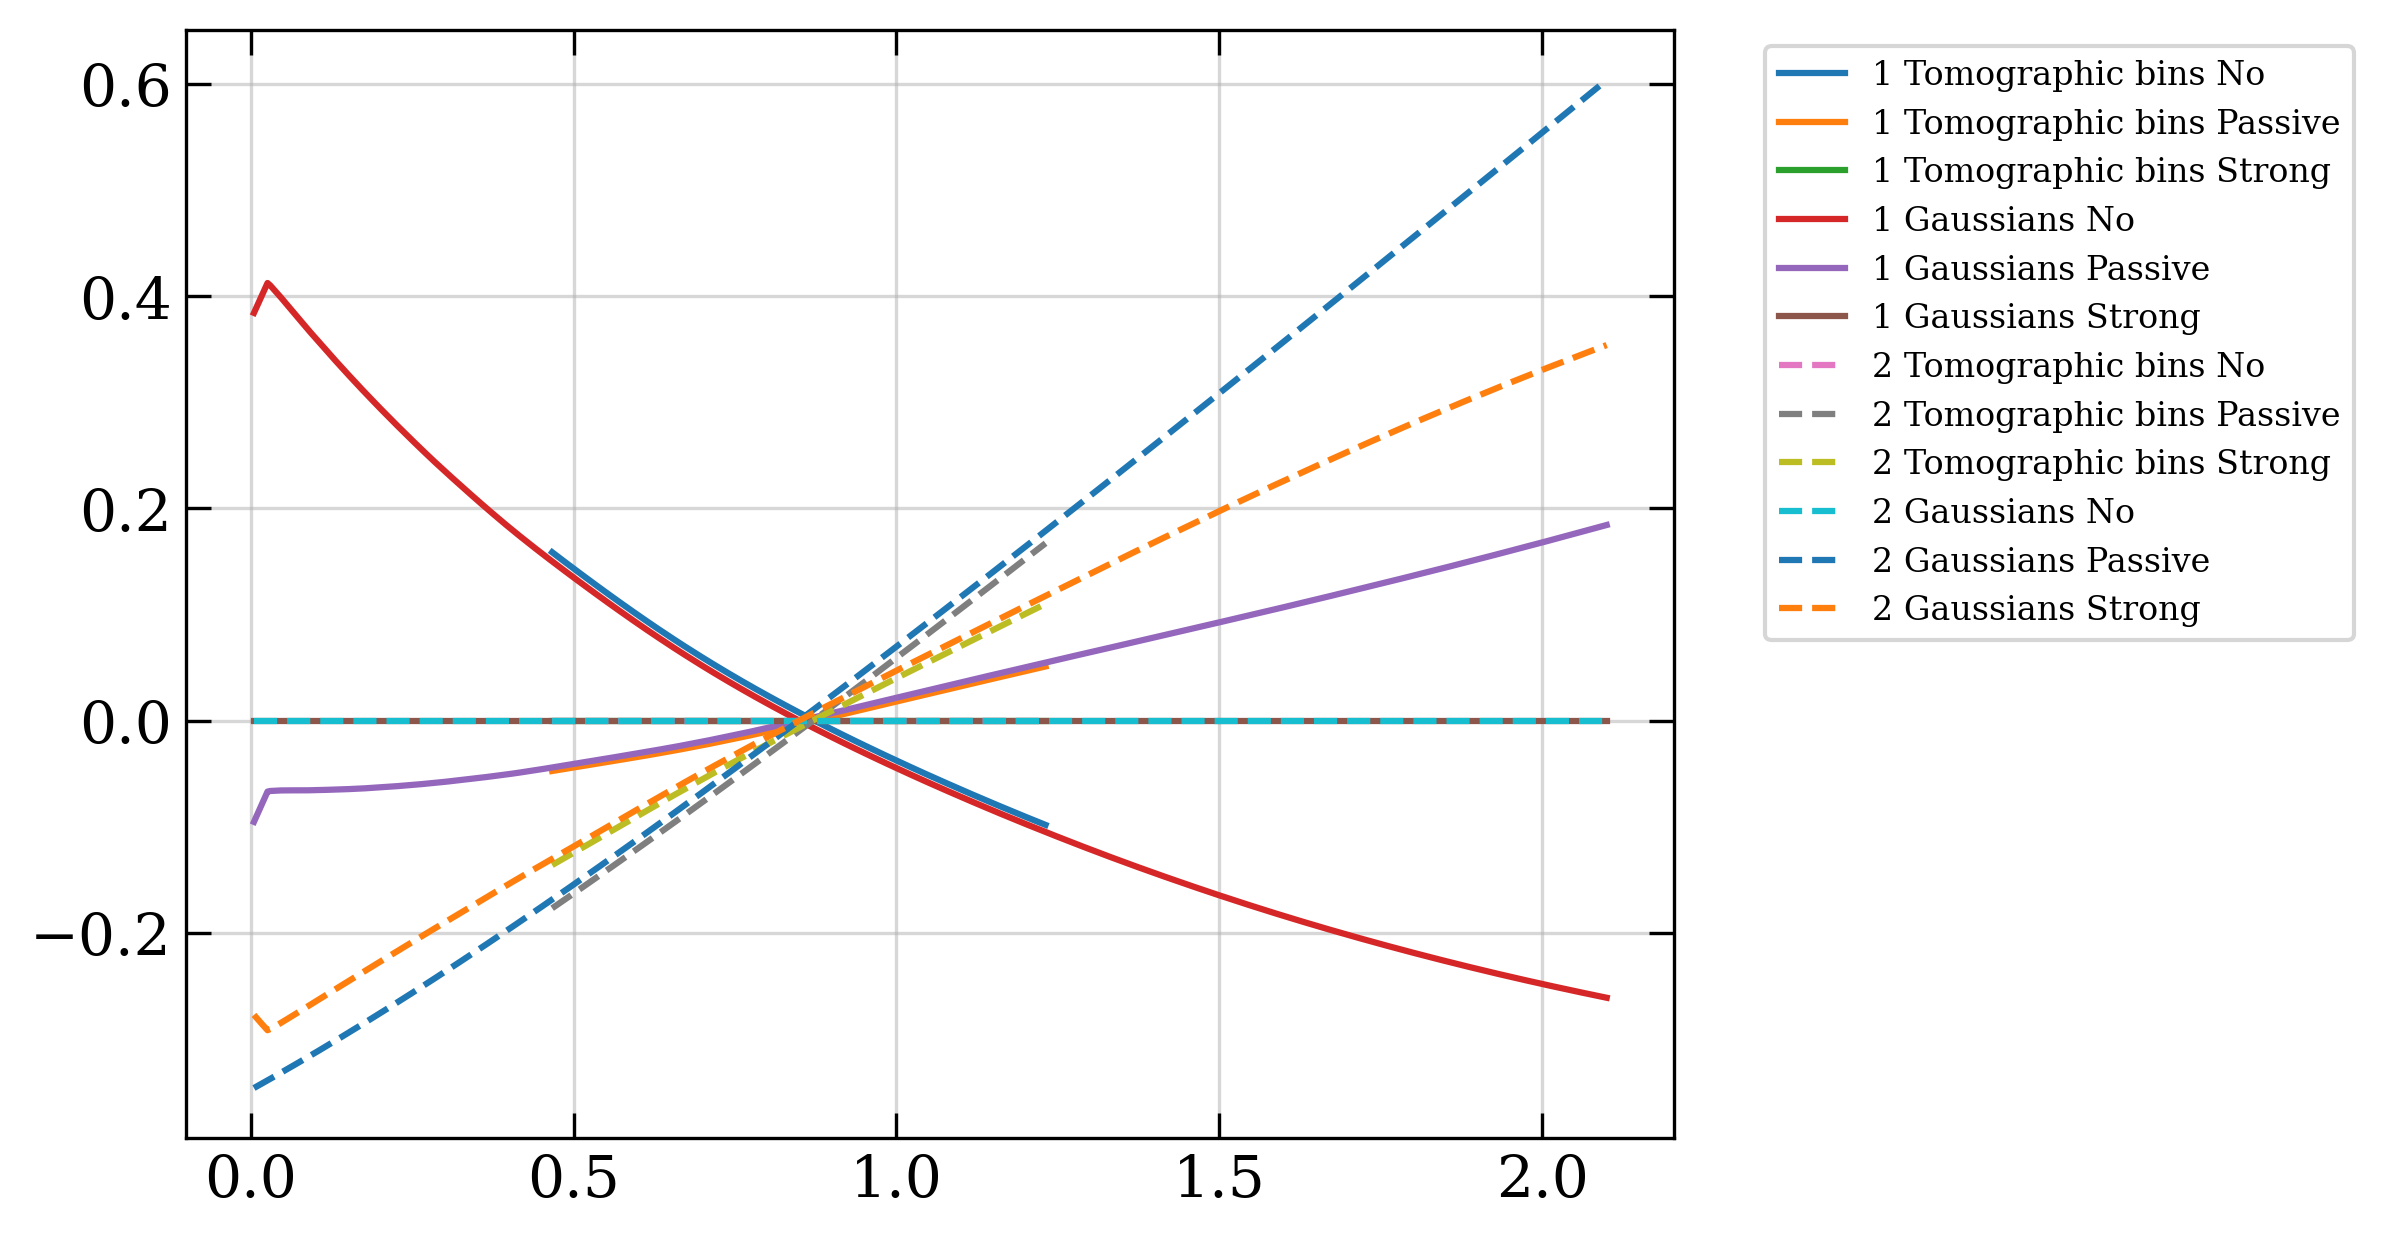

In [62]:
dz = zv[1] - zv[0]
do_nz_fig = False
do_wpp_fig = False
do_bias_fig = False
do_nrel_fig = True

bias_dict = {}
for method in ["1", "2"]:
    for nz_name in nz_models.keys():
        for bias_name in bias_models.keys():
            print(f"Processing method {method}, nz: {nz_name}, bias: {bias_name}")
            bias_t = bias_models[bias_name](zv)

            # n_true
            if method == "1":
                correction = np.array(bias_t) * np.sqrt(wm_v)
            else:
                correction = np.array(bias_t)

            # n_true
            nmeas_bins = np.array(
                [
                    nz_models[nz_name][i] / np.trapezoid(nz_models[nz_name][i], zv)
                    for i in range(len(nz_models[nz_name]))
                ]
            )
            # n_meas
            ntrue_unorm = [(nmeas_bins[i] / correction) for i in range(len(nmeas_bins))]
            ntrue_bins = np.array(
                [
                    ntrue_unorm[i] / np.trapezoid(ntrue_unorm[i], zv)
                    for i in range(len(nmeas_bins))
                ]
            )
            if do_nrel_fig:
                ii = 8
                nm = nmeas_bins[ii]
                nt = ntrue_bins[ii]
                mask_nm = nm > 0
                mask_nt = nt > 0
                nm = nm[mask_nm]
                nt = nt[mask_nm]
                zv_nm = zv[mask_nm]
                plt.plot(
                    zv_nm,
                    (nm - nt) / nt,
                    label=f"{method} {nz_name} {bias_name}",
                    linestyle="-" if method == "1" else "--",
                )

            means_npk = [
                np.trapezoid(nmeas_bins[i] * zv, zv) / np.trapezoid(nmeas_bins[i], zv)
                for i in range(len(nmeas_bins))
            ]
            wpp_measured = [
                np.trapezoid(
                    np.array((bias_t * ntrue_bins[i])) ** 2 * np.array(wm_v), zv
                )
                for i in range(len(ntrue_bins))
            ]
            integ = [
                np.trapezoid(np.array(nmeas_bins[i]) ** 2 * np.array(wm_v), zv)
                for i in range(len(ntrue_bins))
            ]
            bias_corrected = np.array(
                [np.sqrt(wpp_measured[i] / integ[i]) for i in range(len(wpp_measured))]
            )

            if do_nz_fig:
                plt.figure(figsize=(12, 3.5))
                cmap = plt.get_cmap("viridis")

                for i in range(len(ntrue_bins)):
                    plt.plot(
                        zv,
                        ntrue_bins[i],
                        label=r"$n_{\rm true}$" if i == 0 else None,
                        color=cmap((i + 1) / (len(nmeas_bins) + 2)),
                        alpha=0.5,
                    )
                    plt.plot(
                        zv,
                        nmeas_bins[i],
                        linestyle="--",
                        label=r"$n_{pk}$" if i == 0 else None,
                        color=cmap((i + 1) / (len(nmeas_bins) + 2)),
                    )
                plt.grid()
                plt.ylabel(r"$n_{\rm true}(z)$")
                plt.xlabel(r"Redshift")
                plt.xlim(0.0, 2)
                plt.title(
                    f"nz: {nz_name}, Bias: {bias_name} Evolution, Method: {method}",
                    fontsize=10,
                )
                plt.legend()

            if do_wpp_fig:
                plt.figure(dpi=100)
                plt.plot(means_npk, wpp_measured, marker="o", linestyle="--")

                plt.ylabel(r"$w_{pp}^{\rm meas}(z)$")
                plt.xlabel(r"Redshift")

            if do_bias_fig:
                with pm.make_plot(
                    name="bias_correction", figsize=(7, 3), show=True
                ) as (fig, ax):
                    ax.scatter(
                        means_npk,
                        bias_corrected,
                        color="crimson",
                        marker="s",
                        label="Effective bias $w_{pp}$",
                    )
                    ax.plot(zv, bias_t, color="royalblue", label="True bias")
                    ax.legend(loc="upper left", fontsize=9)
                    ax.set_xlabel("Redshift")
                    ax.set_ylabel("Bias")
                    ax.set_xlim(means_npk[0] - 0.1, means_npk[-1] + 0.1)
                    ax.grid(True)
                    ax.set_ylim(0.8, 3.5)
                    ax.set_title(
                        f"nz: {nz_name}, Bias: {bias_name} evolution, Method: {method}",
                        fontsize=10,
                    )

            bias_dict[f"{method}/{nz_name}/{bias_name}/bias_corrected"] = bias_corrected
            bias_dict[f"{method}/{nz_name}/{bias_name}/means_npk"] = means_npk
            bias_dict[f"{method}/{nz_name}/{bias_name}/bias_true"] = bias_t
bias_dict["zv"] = zv

save_dir = Path("data")
save_dir.mkdir(parents=True, exist_ok=True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
np.savez("data/photometric_bias_corrections.npz", **bias_dict)

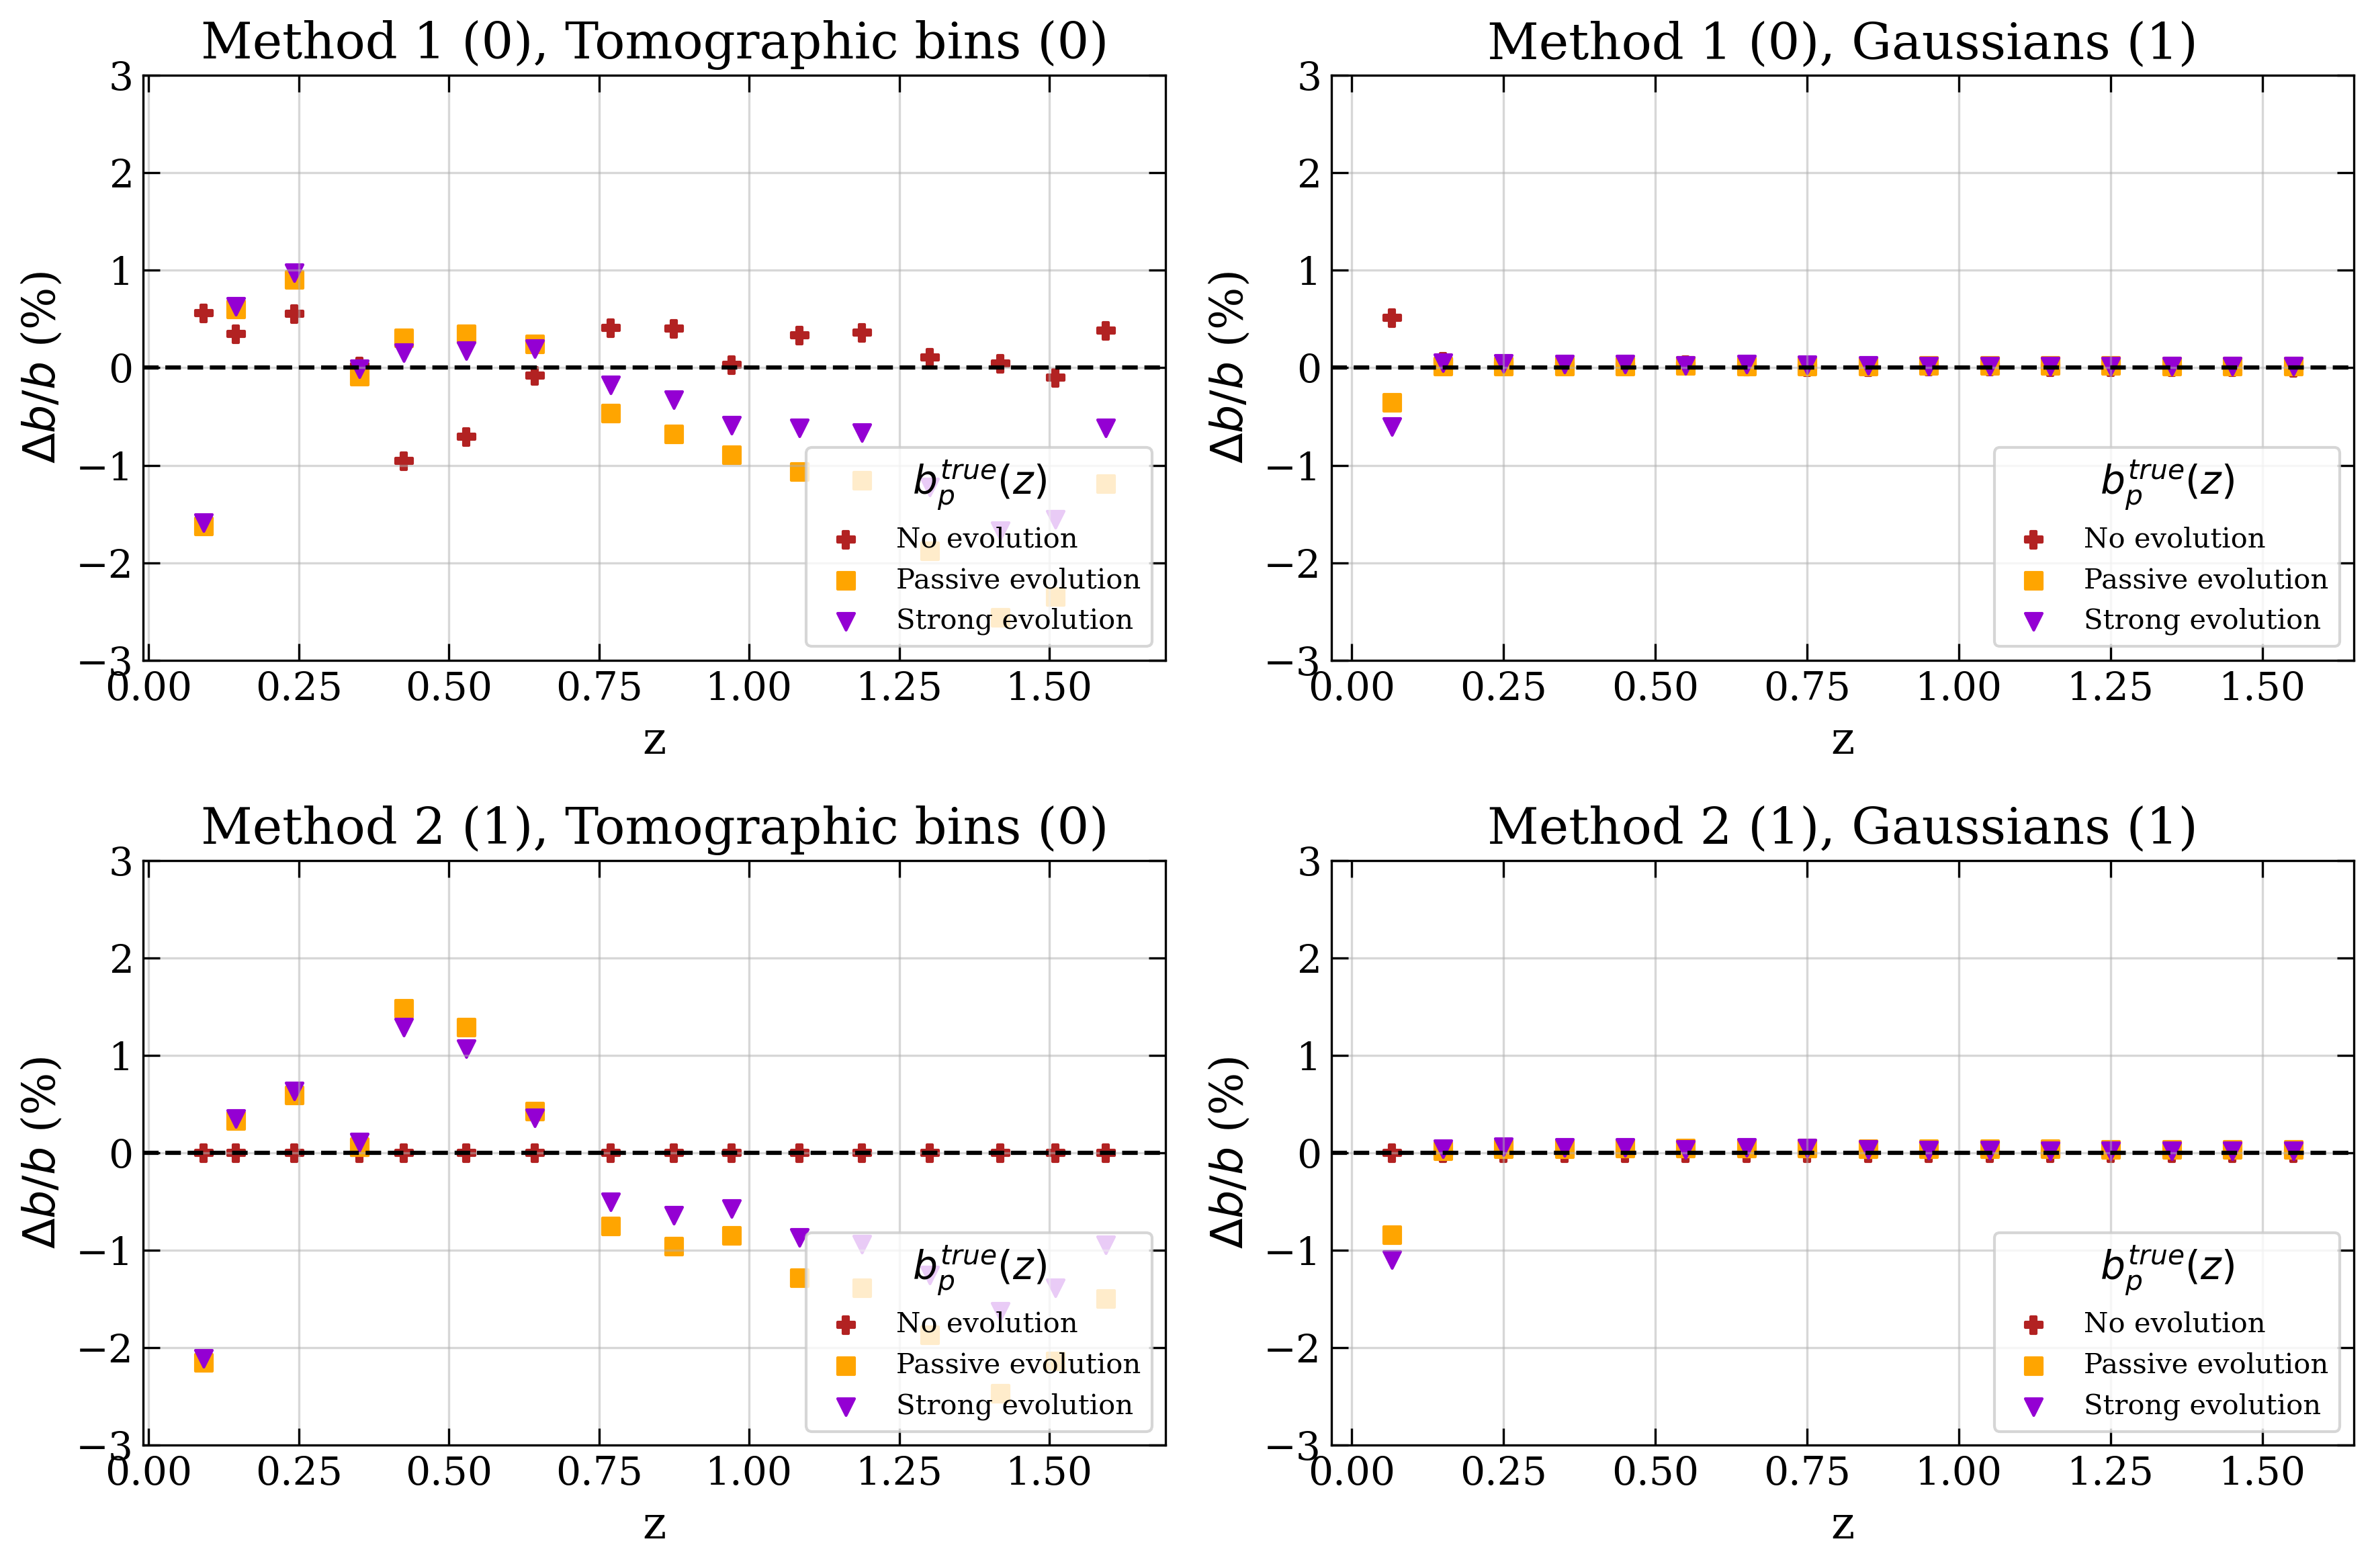

In [63]:
with pm.make_plot(
    name="photoz_bias_correction", figsize=(12, 8), show=True, ncols=2, nrows=2
) as (fig, axs):

    for method_idx, method in enumerate(["1", "2"]):
        for nz_idx, nz_name in enumerate(nz_models.keys()):
            ax = axs[method_idx, nz_idx]
            ax.grid(True)
            ax.axhline(0, color="black", linestyle="--", alpha=1)
            ax.set_ylabel(r"$\Delta b/b$" + " (%)")
            ax.set_xlabel(r"z")

            ax.set_title(f"Method {method} ({method_idx}), {nz_name} ({nz_idx})")

            for bias_name in bias_models.keys():
                bias_corrected = bias_dict[
                    f"{method}/{nz_name}/{bias_name}/bias_corrected"
                ]
                means_npk = bias_dict[f"{method}/{nz_name}/{bias_name}/means_npk"]
                bias_t = bias_dict[f"{method}/{nz_name}/{bias_name}/bias_true"]

                zp = np.arange(len(means_npk)) * 0.1 + 0.05
                bias_disc = interpolate.interp1d(x=zv, y=bias_t)(zp)

                if True:
                    ax.scatter(
                        means_npk,
                        (bias_disc - bias_corrected) / bias_disc * 100,
                        label=f"{bias_name} evolution",
                        color=(
                            "orange"
                            if bias_name == "Passive"
                            else ("firebrick" if bias_name == "No" else "darkviolet")
                        ),
                        marker=(
                            "s"
                            if bias_name == "Passive"
                            else ("P" if bias_name == "No" else "v")
                        ),
                    )
                    ax.set_ylim(-3, 3)
                if False:
                    ax.scatter(means_npk, bias_corrected)
                    ax.plot(zv, bias_t, linestyle="--")
                    ax.set_ylim(0, 4)

                ax.set_xlim(means_npk[0] - 0.1, means_npk[-1] + 0.1)

            ax.legend(title=r"$b_p^{true}(z)$", fontsize=10, loc="lower right")